# Archetypal SAEs ablations

In this notebook, we show the fatal flow of the archetypal SAEs https://arxiv.org/pdf/2502.12892
- The authors claim that the archetypal SAEs are more stable than standard ones, where stability measure how closes are dictionaries trained with a different seed
- However, we suspect that their setting is unfair: they always initialize archetypal SAEs the same while the standard SAEs are initialized at random
- We check that the stability comes solely from the initialization advantage and not al all from archetypal analysis

We test this conjecture by performing the following ablation studies:
- We check that the archetypal SAEs perform the same with archetypal projection switched off
- We check that the standard topK SAEs achieve the same good stability metric when we always initialize them at the k-means centroids and turn off normalization

For fair test, this notebook uses the code and the minimal example provided by the authors of the paper: https://github.com/KempnerInstitute/overcomplete

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# importing the minimal set of lib
# and download the small rabbit dataset

import torch
import numpy as np
import matplotlib.pyplot as plt

from einops import rearrange
from torchvision import transforms

import overcomplete
from overcomplete.metrics import cosine_hungarian_loss



## Load the dataset

In [3]:
# Uncomment for loading the dataset
!wget -O rabbit.npz -q "https://github.com/KempnerInstitute/Overcomplete/blob/main/docs/assets/rabbit.npz?raw=True"

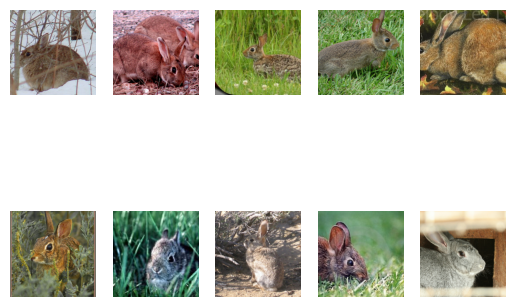

In [4]:
from overcomplete.visualization import show
# show is able to plot any numpy/pil/tensor and handle various
# data format (channel first, last, no channel...)

original_images = np.load('rabbit.npz')['arr_0'].astype(np.uint8)
for i in range(10):
  plt.subplot(2, 5, i+1)
  show(original_images[i])
plt.show()

## Load the DinoV2 vision encoder and get patch emebeddings

In [5]:
images = torch.Tensor(original_images).cuda()
images.shape
from overcomplete.models import DinoV2
model = DinoV2(device='cuda')

images = model.processor(images=images, return_tensors="pt").to("cuda")
last_hidden_states = model.forward_features(images)
patch_tokens = last_hidden_states[:,1:,:]

Activations = rearrange(patch_tokens, 'n t d -> (n t) d')
Activations.shape

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

torch.Size([76800, 384])

## Centering step

In [6]:
activation_mean = Activations.mean(dim=0, keepdim=True)
Activations = Activations - activation_mean

## Train archetypal SAE

### Get centroids from k-means

In [7]:
# before training our SAE, we need to capture "points" that will define the convex hull
# you can think of them as landmark that will guide the dictionary to be close to
# the activations regions.
# here we use kmeans, be sure to have more centroids than concepts.
# for large scale computation, we recommend to use faiss.
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=100, random_state=0, verbose=1)
kmeans.fit(Activations.cpu())

centroids = kmeans.cluster_centers_
centroids.shape

Initialization complete
Iteration 0, inertia 131590999.25284293.
Iteration 1, inertia 84620089.89803368.
Iteration 2, inertia 82684422.71644405.
Iteration 3, inertia 81916421.39955464.
Iteration 4, inertia 81475818.12059405.
Iteration 5, inertia 81149856.64563875.
Iteration 6, inertia 80923110.43622527.
Iteration 7, inertia 80769088.9134335.
Iteration 8, inertia 80650009.8486084.
Iteration 9, inertia 80550080.38124564.
Iteration 10, inertia 80460655.20218101.
Iteration 11, inertia 80378051.9504758.
Iteration 12, inertia 80307172.90553734.
Iteration 13, inertia 80253016.40942457.
Iteration 14, inertia 80204560.83470489.
Iteration 15, inertia 80167241.37250867.
Iteration 16, inertia 80135341.12892765.
Iteration 17, inertia 80115058.88796848.
Iteration 18, inertia 80098313.06851862.
Iteration 19, inertia 80082952.31523463.
Iteration 20, inertia 80064886.38826293.
Iteration 21, inertia 80048749.66040611.
Iteration 22, inertia 80030610.86424181.
Iteration 23, inertia 80012741.30068964.
Iter

(100, 384)

In [8]:
# now the funny part, lets train an archetypal topk sae
# we need a dataloader, a criterion and an optimizer
from torch.utils.data import DataLoader, TensorDataset
from overcomplete.sae import RATopKSAE, train_sae

sae = RATopKSAE(Activations.shape[-1], nb_concepts=30, top_k=3, points=torch.tensor(centroids).float().cuda(),
                delta=0.2, device='cuda')

dataloader = torch.utils.data.DataLoader(TensorDataset(Activations), batch_size=1024, shuffle=True)
optimizer = torch.optim.Adam(sae.parameters(), lr=5e-3)

def criterion(x, x_hat, pre_codes, codes, dictionary):
  loss = (x - x_hat).square().mean()

  # add reanimation loss to avoid dead codes:
  is_dead = ((codes > 0).sum(dim=0) == 0).float().detach()
  reanim_loss = (pre_codes * is_dead[None, :]).mean()
  loss -= reanim_loss * 1e-3

  return loss

In [9]:
logs = train_sae(sae, dataloader, criterion, optimizer, nb_epochs=30, device='cuda')

Epoch[1/30], Loss: 3.8104, R2: 0.2412, L0: 2.9991, Dead Features: 0.0%, Time: 0.4613 seconds
Epoch[2/30], Loss: 2.7778, R2: 0.4470, L0: 3.0000, Dead Features: 0.0%, Time: 0.1982 seconds
Epoch[3/30], Loss: 2.7594, R2: 0.4507, L0: 3.0000, Dead Features: 0.0%, Time: 0.2682 seconds
Epoch[4/30], Loss: 2.7595, R2: 0.4507, L0: 3.0000, Dead Features: 0.0%, Time: 0.1963 seconds
Epoch[5/30], Loss: 2.7468, R2: 0.4532, L0: 3.0000, Dead Features: 0.0%, Time: 0.1957 seconds
Epoch[6/30], Loss: 2.7437, R2: 0.4538, L0: 3.0000, Dead Features: 0.0%, Time: 0.2660 seconds
Epoch[7/30], Loss: 2.7439, R2: 0.4538, L0: 2.9999, Dead Features: 0.0%, Time: 0.1528 seconds
Epoch[8/30], Loss: 2.7502, R2: 0.4525, L0: 3.0000, Dead Features: 0.0%, Time: 0.2206 seconds
Epoch[9/30], Loss: 2.7398, R2: 0.4546, L0: 3.0000, Dead Features: 0.0%, Time: 0.1519 seconds
Epoch[10/30], Loss: 2.7413, R2: 0.4543, L0: 3.0000, Dead Features: 0.0%, Time: 0.1507 seconds
Epoch[11/30], Loss: 2.7449, R2: 0.4536, L0: 3.0000, Dead Features: 0.

### Visualize SAE features as heatmaps

Concept 0


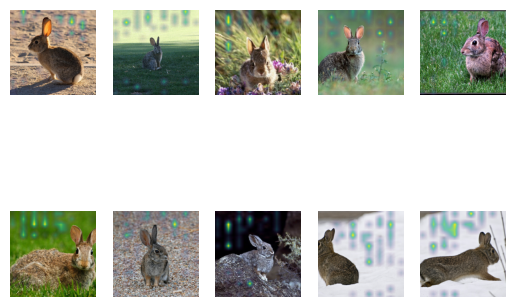

Concept 1


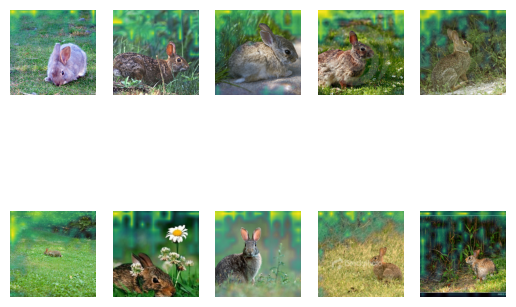

Concept 2


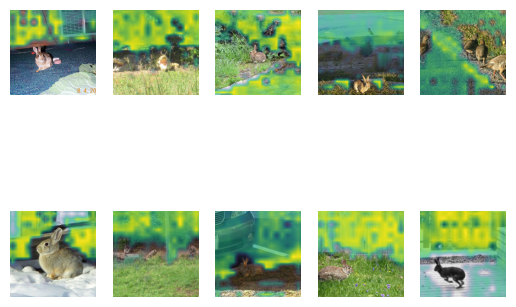

Concept 3


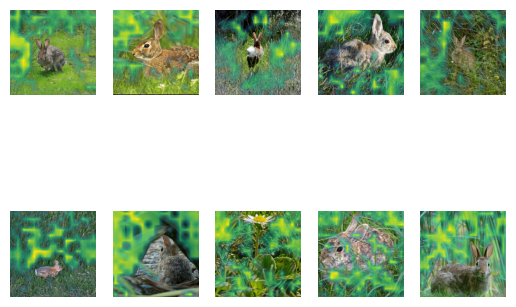

Concept 4


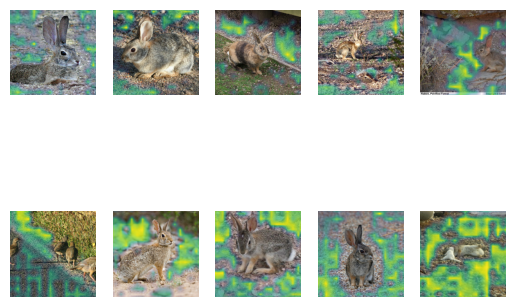

Concept 5


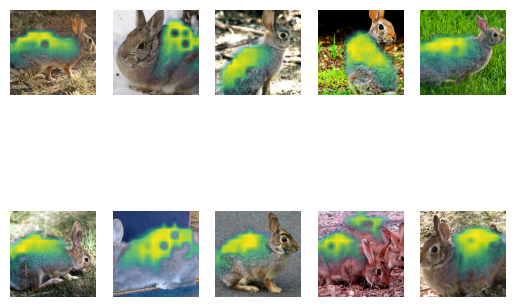

Concept 6


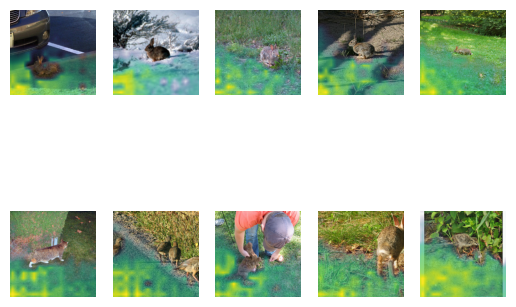

Concept 7


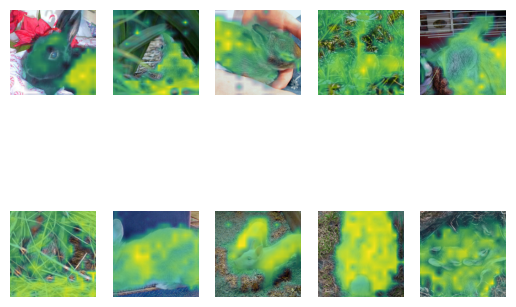

Concept 8


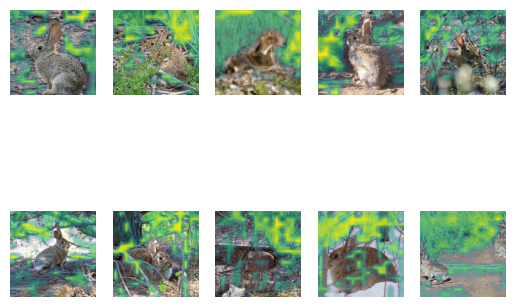

Concept 9


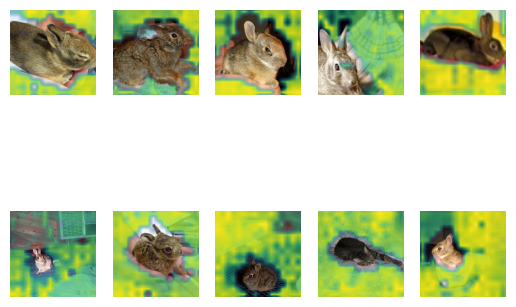

In [10]:
from overcomplete.visualization import overlay_top_heatmaps
# great, now let inspect the results !
# first we reshape the code to see them patch-wise
# then we will use `overlay_top_heatmaps`
# a little function to show the top concepts

sae = sae.eval()

with torch.no_grad():
  pre_codes, codes = sae.encode(Activations)

codes = rearrange(codes, '(n w h) d -> n w h d', w=16, h=16)

for i in range(10):
  print('Concept', i)
  overlay_top_heatmaps(original_images, codes, concept_id=i)
  plt.show()

## Measuring stability

### Train two classical topk saes on different seeds

In [11]:
# classical topk
from overcomplete.sae import TopKSAE

nb_concepts = 200

def train(sae):
  dataloader = torch.utils.data.DataLoader(TensorDataset(Activations), batch_size=1024, shuffle=True)
  optimizer = torch.optim.Adam(sae.parameters(), lr=5e-3)
  logs = train_sae(sae, dataloader, criterion, optimizer, nb_epochs=20, device='cuda')

sae1 = TopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda')
train(sae1)

sae2 = TopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda')
train(sae2)


Epoch[1/20], Loss: 2.9480, R2: 0.4131, L0: 3.0000, Dead Features: 0.0%, Time: 0.1909 seconds
Epoch[2/20], Loss: 2.3037, R2: 0.5414, L0: 3.0000, Dead Features: 6.5%, Time: 0.2925 seconds
Epoch[3/20], Loss: 2.2417, R2: 0.5537, L0: 3.0000, Dead Features: 13.0%, Time: 0.1848 seconds
Epoch[4/20], Loss: 2.2180, R2: 0.5584, L0: 3.0000, Dead Features: 16.0%, Time: 0.1880 seconds
Epoch[5/20], Loss: 2.2022, R2: 0.5616, L0: 3.0000, Dead Features: 13.0%, Time: 0.2646 seconds
Epoch[6/20], Loss: 2.1922, R2: 0.5636, L0: 3.0000, Dead Features: 6.0%, Time: 0.1876 seconds
Epoch[7/20], Loss: 2.1867, R2: 0.5647, L0: 3.0000, Dead Features: 8.0%, Time: 0.2590 seconds
Epoch[8/20], Loss: 2.1791, R2: 0.5662, L0: 3.0000, Dead Features: 6.5%, Time: 0.1538 seconds
Epoch[9/20], Loss: 2.1717, R2: 0.5677, L0: 3.0000, Dead Features: 3.0%, Time: 0.1454 seconds
Epoch[10/20], Loss: 2.1647, R2: 0.5691, L0: 3.0000, Dead Features: 6.0%, Time: 0.2135 seconds
Epoch[11/20], Loss: 2.1583, R2: 0.5703, L0: 3.0000, Dead Features:

### Train two archetypal SAEs on different seeds

In [12]:
# now with archetypal
# classical topk
rasae1 = RATopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', points=torch.tensor(centroids).float().cuda(), delta=0.1)
train(rasae1)

rasae2 = RATopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', points=torch.tensor(centroids).float().cuda(), delta=0.1)
train(rasae2)


Epoch[1/20], Loss: 3.9347, R2: 0.2174, L0: 3.0000, Dead Features: 0.0%, Time: 0.1558 seconds
Epoch[2/20], Loss: 2.4247, R2: 0.5173, L0: 3.0000, Dead Features: 0.0%, Time: 0.2243 seconds
Epoch[3/20], Loss: 2.3671, R2: 0.5288, L0: 3.0000, Dead Features: 1.0%, Time: 0.1547 seconds
Epoch[4/20], Loss: 2.3533, R2: 0.5315, L0: 3.0000, Dead Features: 2.5%, Time: 0.2242 seconds
Epoch[5/20], Loss: 2.3340, R2: 0.5354, L0: 3.0000, Dead Features: 3.5%, Time: 0.1547 seconds
Epoch[6/20], Loss: 2.3272, R2: 0.5367, L0: 3.0000, Dead Features: 5.0%, Time: 0.1543 seconds
Epoch[7/20], Loss: 2.3297, R2: 0.5362, L0: 3.0000, Dead Features: 12.0%, Time: 0.2240 seconds
Epoch[8/20], Loss: 2.3154, R2: 0.5391, L0: 3.0000, Dead Features: 10.0%, Time: 0.1546 seconds
Epoch[9/20], Loss: 2.3128, R2: 0.5396, L0: 3.0000, Dead Features: 17.5%, Time: 0.2224 seconds
Epoch[10/20], Loss: 2.3042, R2: 0.5413, L0: 3.0000, Dead Features: 25.5%, Time: 0.1541 seconds
Epoch[11/20], Loss: 2.3020, R2: 0.5417, L0: 3.0000, Dead Features

In [13]:
d1, d2 = sae1.get_dictionary(), sae2.get_dictionary()
d3, d4 = rasae1.get_dictionary(), rasae2.get_dictionary()

score_classic_sae = cosine_hungarian_loss(d1.detach(), d2.detach()) / d1.shape[0]
score_archetypal_sae = cosine_hungarian_loss(d3.detach(), d4.detach()) / d1.shape[0]

print(f'Hungarian distance Classic SAE: {score_classic_sae}')
print(f'Hungarian distance Archetypal SAE: {score_archetypal_sae}')

Hungarian distance Classic SAE: 0.4186945724487305
Hungarian distance Archetypal SAE: 0.24465503692626953


Here the authors claim that the archetypal SAEs are more stable, in our ablations below we show that their argument is flawed and the stability improvements comes solely from fixing the dictionary initialization. It has nothing to do with their archetypal analysis.

### Turn off archetypal projection in archetypal SAEs

In [14]:
# now with archetypal
# classical topk
rasae1_ablated = RATopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', points=torch.tensor(centroids).float().cuda(), delta=0.1, projection=False)
train(rasae1_ablated)

rasae2_ablated = RATopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', points=torch.tensor(centroids).float().cuda(), delta=0.1, projection=False)
train(rasae2_ablated)

d5, d6 = rasae1_ablated.get_dictionary(), rasae2_ablated.get_dictionary()
score_archetypal_sae_ablated = cosine_hungarian_loss(d5.detach(), d6.detach()) / nb_concepts
print(f'Hungarian distance Archetypal SAE Ablated: {score_archetypal_sae_ablated}')

Epoch[1/20], Loss: 3.5891, R2: 0.2850, L0: 3.0000, Dead Features: 0.0%, Time: 0.1818 seconds
Epoch[2/20], Loss: 2.9405, R2: 0.4146, L0: 3.0000, Dead Features: 14.5%, Time: 0.2549 seconds
Epoch[3/20], Loss: 3.2468, R2: 0.3538, L0: 3.0000, Dead Features: 5.5%, Time: 0.1806 seconds
Epoch[4/20], Loss: 3.0660, R2: 0.3897, L0: 3.0000, Dead Features: 4.0%, Time: 0.2549 seconds
Epoch[5/20], Loss: 2.9319, R2: 0.4164, L0: 3.0000, Dead Features: 3.0%, Time: 0.1794 seconds
Epoch[6/20], Loss: 2.7798, R2: 0.4466, L0: 3.0000, Dead Features: 1.5%, Time: 0.1839 seconds
Epoch[7/20], Loss: 2.7094, R2: 0.4607, L0: 3.0000, Dead Features: 2.0%, Time: 0.2511 seconds
Epoch[8/20], Loss: 2.5762, R2: 0.4872, L0: 3.0000, Dead Features: 1.0%, Time: 0.1794 seconds
Epoch[9/20], Loss: 2.5312, R2: 0.4962, L0: 3.0000, Dead Features: 0.5%, Time: 0.2529 seconds
Epoch[10/20], Loss: 2.4424, R2: 0.5139, L0: 3.0000, Dead Features: 0.5%, Time: 0.1790 seconds
Epoch[11/20], Loss: 2.3819, R2: 0.5259, L0: 3.0000, Dead Features: 1

## Fixing initialization of topk SAEs

In [15]:
C=torch.tensor(centroids).float().cuda()
nb_concepts = 200
nb_candidates = C.shape[0]
W = torch.eye(nb_concepts, nb_candidates, device="cuda")
D = W @ C
dictionary_params = {"initializer": D, "normalization": "identity"}

In [16]:
sae1_fixed_init = TopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', dictionary_params=dictionary_params)
train(sae1_fixed_init)

sae2_fixed_init = TopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', dictionary_params=dictionary_params)
train(sae2_fixed_init)

d7, d8 = sae1_fixed_init.get_dictionary(), sae2_fixed_init.get_dictionary()
score_classic_sae_fixed_init = cosine_hungarian_loss(d7.detach(), d8.detach()) / nb_concepts
print(f'Hungarian distance Classic SAE with fixed init: {score_classic_sae_fixed_init}')

/home/m.brzozowsk3/projects/ablating-archetypes/overcomplete/sae/dictionary.py:154: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initializer, device=device)


Epoch[1/20], Loss: 3.5889, R2: 0.2865, L0: 3.0000, Dead Features: 0.0%, Time: 0.2125 seconds
Epoch[2/20], Loss: 2.8634, R2: 0.4300, L0: 3.0000, Dead Features: 14.0%, Time: 0.1423 seconds
Epoch[3/20], Loss: 3.3827, R2: 0.3266, L0: 3.0000, Dead Features: 7.0%, Time: 0.1418 seconds
Epoch[4/20], Loss: 3.1264, R2: 0.3776, L0: 3.0000, Dead Features: 4.0%, Time: 0.2120 seconds
Epoch[5/20], Loss: 2.8819, R2: 0.4263, L0: 3.0000, Dead Features: 4.0%, Time: 0.1423 seconds
Epoch[6/20], Loss: 2.7817, R2: 0.4463, L0: 3.0000, Dead Features: 1.0%, Time: 0.2117 seconds
Epoch[7/20], Loss: 2.7404, R2: 0.4546, L0: 3.0000, Dead Features: 2.0%, Time: 0.1412 seconds
Epoch[8/20], Loss: 2.5980, R2: 0.4829, L0: 3.0000, Dead Features: 1.5%, Time: 0.1432 seconds
Epoch[9/20], Loss: 2.5451, R2: 0.4934, L0: 3.0000, Dead Features: 0.0%, Time: 0.2111 seconds
Epoch[10/20], Loss: 2.4531, R2: 0.5117, L0: 3.0000, Dead Features: 0.5%, Time: 0.1412 seconds
Epoch[11/20], Loss: 2.4003, R2: 0.5223, L0: 3.0000, Dead Features: 1

In [17]:
print(f'Hungarian distance Classic SAE: {score_classic_sae}')
print(f'Hungarian distance Archetypal SAE: {score_archetypal_sae}')
print(f'Hungarian distance Archetypal SAE Ablated: {score_archetypal_sae_ablated}')
print(f'Hungarian distance Classic SAE with fixed init: {score_classic_sae_fixed_init}')

Hungarian distance Classic SAE: 0.4186945724487305
Hungarian distance Archetypal SAE: 0.24465503692626953
Hungarian distance Archetypal SAE Ablated: 0.08119011878967285
Hungarian distance Classic SAE with fixed init: 0.07242825508117676
